## Smoothing Methods (Holt-Winters)

Düzeltme Yöntemleri (Zaman Serilerinde Gürültüyü Azaltma)

In [1]:
#
# Bir zaman serisinde (Time Series) trend, mevsimsellik ve kalıntı (gürültü) 
# bileşenlerinin birbirine etkisini yumuşatıp öngörü yeteneğimizi artırmak için 
# Üstel Düzeltme (Exponential Smoothing) gibi yöntemlere başvururuz.
# Bu dosyada üç önemli yöntemi uygulayacağız:
# 1. Single Exponential Smoothing (SES) - Sadece Durağan serilerde yatay (Level) etkiyi yakalar.
# 2. Double Exponential Smoothing (DES) - Yatay etki + Trend (eğim) etkisini yakalar.
# 3. Triple Exponential Smoothing (TES) - Yatay etki + Trend + Mevsimselliği (Seasonality) aynı anda yakalar. Holt-Winters olarak da bilinir.

import itertools  # Hiperparametre kombinasyonlarını oluşturmak için kullanılacak iterasyon modülü.
import warnings   # Konsoldaki uyarıları görmezden gelmek için eklendi.
import matplotlib.pyplot as plt  # Veriyi ve tahminleri grafiğe dökmek (görselleştirme) için kullanılır.
import numpy as np  # Matematiksel ve matris operasyonları için güçlü bir kütüphane.
import pandas as pd # Veri manipülasyonu, tablo (dataframe) işlemleri için Pandas kütüphanesi şart.
import statsmodels.api as sm  # İstatistiksel modellerin bulunduğu gelişmiş kütüphanedir. Veri seti de buradan çekilecek.
from sklearn.metrics import mean_absolute_error  # Modelin hata payını ölçmek için kullanacağımız bir metrik (Ortalama Mutlak Hata).
from statsmodels.tsa.holtwinters import ExponentialSmoothing # Çift (DES) ve Üçlü (TES) üstel düzeltme modelleri için çağrıldı.
from statsmodels.tsa.holtwinters import SimpleExpSmoothing   # Sadece Tek (SES) üstel düzeltme hesaplamaları için çağrıldı.
from statsmodels.tsa.seasonal import seasonal_decompose      # Zaman serisi verisini Trend, Mevsimsellik, Kalıntı şeklinde parçalamak için kullanılır.
import statsmodels.tsa.api as smt # Zaman serisi modülü.

# Kod çıktısındaki gereksiz uyarı mesajlarını (deprecation warning vs.) ekrandan gizler, temiz bir görüntü sağlar.
warnings.filterwarnings('ignore')

## Veri Seti (Dataset)

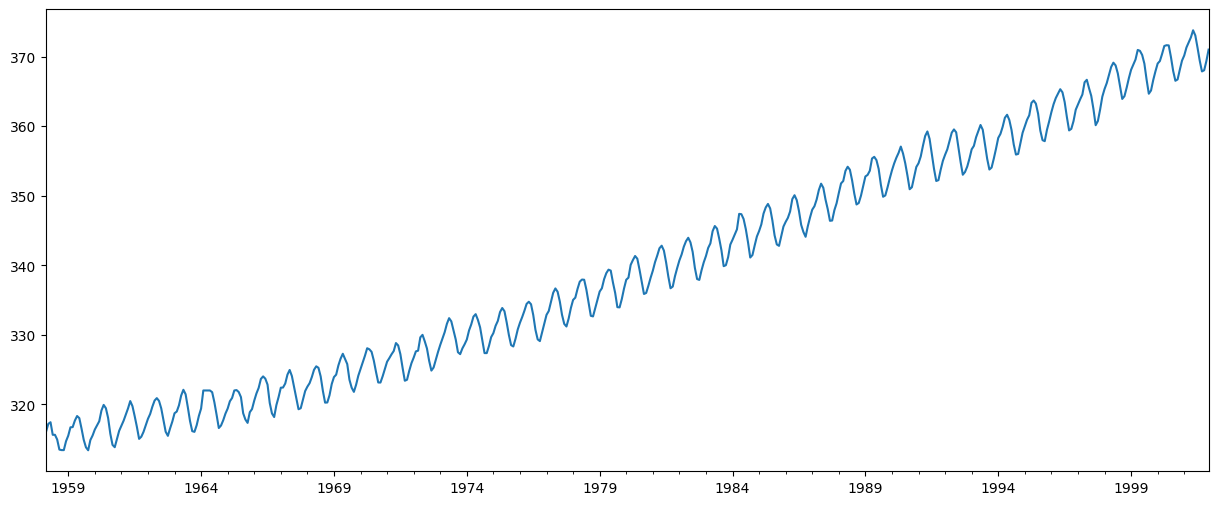

In [2]:
# Atmospheric CO2 from Continuous Air Samples at Mauna Loa Observatory, Hawaii, U.S.A.
# Period of Record: March 1958 - December 2001 (Kayıtlı olunan süreç referansı)
# Veride Hawaii'de ölçülen atmosferik Karbondioksit (CO2) miktarı aylık döngüyle yer almaktadır.

data = sm.datasets.co2.load_pandas() # Kütüphane içerisinde hazır duran CO2 zaman serisi verisi indirilir.
y = data.data # Data objesinden yalnızca asıl veri kısmını sıyırıp alıyoruz, 'y' isminde muhafaza ediyoruz.

# 'resample' ile veriyi aylık başlangıç noktasına ('MS' -> Month Start) göre gruplayıp ortalamalarını alıyoruz.
# Çünkü orijinal veride günler vs olabilir, analiz boyunca aylık bir periyotla çalışıyoruz.
y = y['co2'].resample('MS').mean()

# Zaman serisi analizinde boş veriler (NaN) analizi patlatır. Kaç tane boş değer var kontrol ediyoruz.
y.isnull().sum()

# Eksik verileri doldurmak için "bfill" (backward fill) yöntemini seçiyoruz. 
# Bu metot şunu der: "Eğer burası boşsa, bir sonraki dolu değeri al ve burayı doldur."
y = y.fillna(y.bfill())

# Her şey hazır, şimdi verimiz nasıl bir yapıya (trend var mı vs.) sahip görmek için çizdiriyoruz.
y.plot(figsize=(15, 6))
plt.show() # Grafiği ekrana bas.

## Holdout (Veriyi Eğitim ve Test Olarak İkiye Ayırma)

In [3]:
# Modelimizin ezberlemeyip gerçekten öğrendiğinden nasıl emin oluruz?
# Tabii ki görmediği veriler sayesinde! Serinin bir parçasını eğitim (train), geri kalanını test için bölelim.

train = y[:'1997-12-01'] # 1998'den önceki tüm eski veriler modeli eğitmek için ayrıldı.
len(train)  # 478 ay eğitim kümemizin uzunluğu.

# 1998'ilk ayından 2001'in sonuna kadar (seri sonu) olan son periyodu da modeli sınamak için Test set olarak aldık.
test = y['1998-01-01':]
len(test)  # 48 ay, tahminde kıyaslayacağımız süremiz.

48

## Zaman Serisi Yapısal Analizi (Structural Analysis)

Result: Non-Stationary (H0: non-stationary, p-value: 0.999)


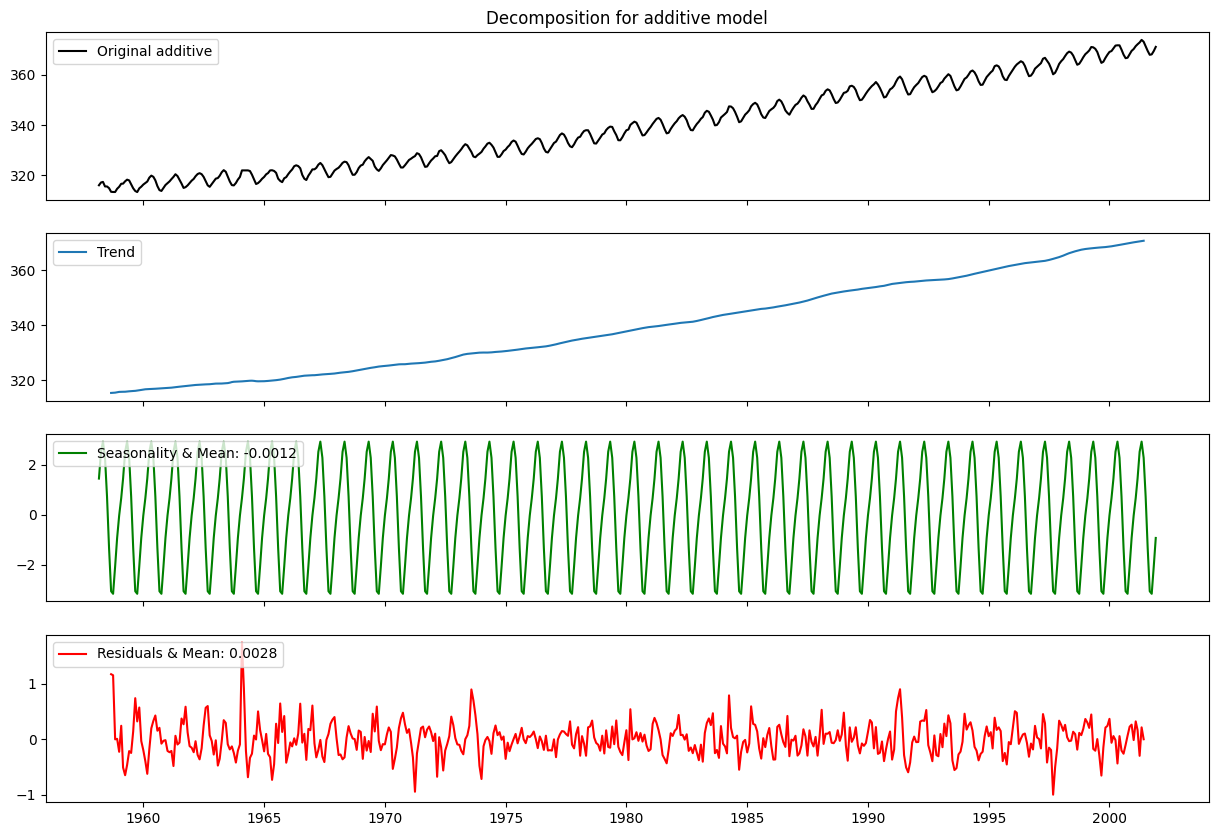

Result: Non-Stationary (H0: non-stationary, p-value: 0.999)


In [4]:
# Durağanlık Testi (Dickey-Fuller Testi)
# Bir serinin durağan olması demek; istatistiksel özellikleri (ortalaması, varyansı vs) zaman içinde değişmiyor anlamına gelir.

def is_stationary(y):

    # "HO: Non-stationary" -> Dickey-Fuller testinin Hipotez 0'ı derki: Seri DURAĞAN DEĞİLDİR.
    # "H1: Stationary" -> Hipotez 1: Hayır, seri DURAĞANDIR.

    # adfuller metodu Dickey-Fuller testini yapar ve sonuçlar listesi döner. Bize [1]. indeksli yerdeki 'p-value' lazımdır.
    p_value = sm.tsa.stattools.adfuller(y)[1] 
    
    # p-value < 0.05 ise H0 hipotezini reddederiz ve "Durağandır" sonucuna ulaşırız. Değilse reddedemeyiz.
    if p_value < 0.05:
        print(F"Result: Stationary (H0: non-stationary, p-value: {round(p_value, 3)})")
    else:
        print(F"Result: Non-Stationary (H0: non-stationary, p-value: {round(p_value, 3)})")

is_stationary(y) # CO2 verimiz muhtemelen durağan değil (yukarı doğru agresif trendi olduğundan) çıkar.

# Zaman Serisi Bileşenleri ve Durağanlık Testi (Decompose işlemi)
# Serimizin iç dünyasına inip 'Trend', 'Mevsimsellik' ve elde kalan 'Artık (Residual)' kısımlarını grafikte bölüyoruz.
def ts_decompose(y, model="additive", stationary=False):
    # 'seasonal_decompose' ile yukarıda saydığım bölümleri ayırıyoruz. (additive = Toplamsal model bazında)
    result = seasonal_decompose(y, model=model)
    fig, axes = plt.subplots(4, 1, sharex=True, sharey=False) # Alt alta 4 adet satırlık görsel paneli açarız.
    fig.set_figheight(10) # Figür yüksekliği vs. boyutları ayarlanır.
    fig.set_figwidth(15)

    # 1. Eksen (Axes 0): Serinin Orjinal Halini Çiz:
    axes[0].set_title("Decomposition for " + model + " model")
    axes[0].plot(y, 'k', label='Original ' + model)
    axes[0].legend(loc='upper left')

    # 2. Eksen (Axes 1): Seriden çıkarılan saf Yöneliş (Trend) Çizilir:
    axes[1].plot(result.trend, label='Trend')
    axes[1].legend(loc='upper left')

    # 3. Eksen (Axes 2): Seride bulunan döngüsel paternler, mevsimsellik izleri çizilir.
    axes[2].plot(result.seasonal, 'g', label='Seasonality & Mean: ' + str(round(result.seasonal.mean(), 4)))
    axes[2].legend(loc='upper left')

    # 4. Eksen (Axes 3): Ne trend ile ne mevsimsellik ile açıklanamayan, seride hata oranını veren Kalan Tortu. (Noise)
    axes[3].plot(result.resid, 'r', label='Residuals & Mean: ' + str(round(result.resid.mean(), 4)))
    axes[3].legend(loc='upper left')
    plt.show(block=True) 

    # Fonksiyon çağrıldığında parametre olarak stationary=True gelmişse durağanlık testi çalışıp çıktı verir.
    if stationary:
        is_stationary(y)

ts_decompose(y, stationary=True) # Analizi gerçekleştirip grafikleri kontrol ediyoruz.

## Single Exponential Smoothing (SES - Tekil Üstel Düzeltme)

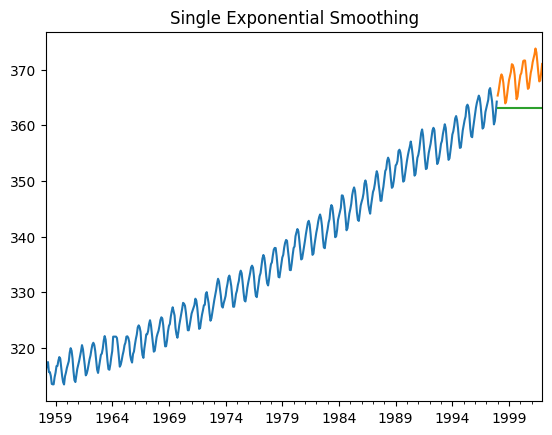

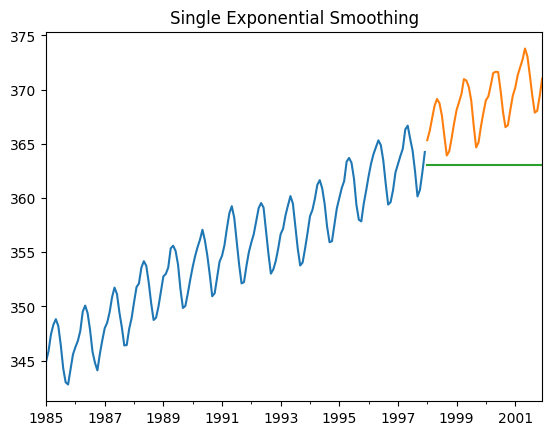

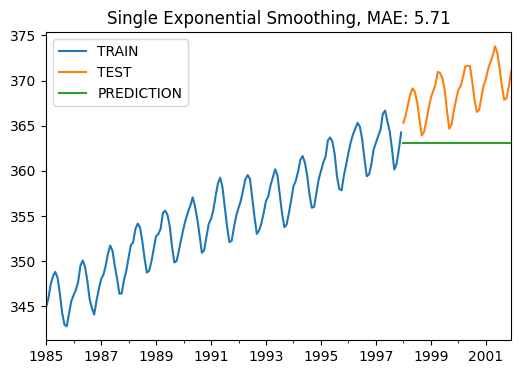

{'smoothing_level': np.float64(0.5),
 'smoothing_trend': np.float64(nan),
 'smoothing_seasonal': np.float64(nan),
 'damping_trend': nan,
 'initial_level': np.float64(316.1),
 'initial_trend': np.float64(nan),
 'initial_seasons': array([], dtype=float64),
 'use_boxcox': False,
 'lamda': None,
 'remove_bias': False}

In [5]:
# SES Yalnızca Seviyeyi (Level) algılar. Trend veya mevsimsellik varsa bu model başarısız olur çünkü onları anlayamaz!

ses_model = SimpleExpSmoothing(train).fit(smoothing_level=0.5) # Train verisine SES modelini kuruyoruz. smoothing_level dediğimiz alfa ağırlığıdır. (Yani geçmiş ağırlığa %50 önem ver).

y_pred = ses_model.forecast(48) # Gelecek 48 periyot (yani testimizin uzunluğu kadar ay) için SES'e öngörü yaptırıyoruz.

mean_absolute_error(test, y_pred) # Elde edilen tahminlerle test seti arasındeki hata puanına (MAE) bakıyoruz.

# Çıkanları gözlemlemek için grafiği yazalım:
train.plot(title="Single Exponential Smoothing")
test.plot()
y_pred.plot()
plt.show()

# Grafikteki bozulma 1985'ten dolayıysa sadece 1985'ten sonrasını yakınlaştırmak için bu hücredeki gibi plot edilebiliriz.
train["1985":].plot(title="Single Exponential Smoothing")
test.plot()
y_pred.plot()
plt.show()

# Tahminleri ve Test Verilerini Görselliğe dönüştüren yardımcı kolay bir fonksiyon yazıyoruz. 
# Bu sayede her seferinde uzun uzun 5-6 satır çizim koduna maruz kalmayacağız.
def plot_co2(train, test, y_pred, title):
    mae = mean_absolute_error(test, y_pred)
    train["1985":].plot(legend=True, label="TRAIN", title=f"{title}, MAE: {round(mae,2)}")
    test.plot(legend=True, label="TEST", figsize=(6, 4))
    y_pred.plot(legend=True, label="PREDICTION")
    plt.show()

plot_co2(train, test, y_pred, "Single Exponential Smoothing") # Test edelim, gayet güzel yansıtıyor.

ses_model.params # Model içerisine yerleşen istatistiksel sabitleri/parametre parametre sözlüğünü inceleyebilmek için.

## Hyperparameter Optimization (Hiperparametre Optimizasyonu)

In [6]:
# Biz elle smoothing_level=0.5 seçmiştik ancak belki en optimum hata payını 0.7 sağlayacak? 
# Bunu anlamak adına modelin bir optimizasyon döngüsünden geçerek farklı olasılıkları test etmesi gerekir.

def ses_optimizer(train, alphas, step=48):
    # Başlangıçta en iyi alfa değerini boş ve hata payını sonsuz (çok büyük ulaşılamaz bir limit) bırakıyoruz.
    best_alpha, best_mae = None, float("inf")

    # Gelebilecek tüm olası alfalar (parametreler) içinde deneme yapacağız.
    for alpha in alphas:
        # Seçilen alfanın seviyesiyle modeli eğit ve tahmin oluştur:
        ses_model = SimpleExpSmoothing(train).fit(smoothing_level=alpha)
        y_pred = ses_model.forecast(step)
        mae = mean_absolute_error(test, y_pred) # MAE (Hatayı) ölç!

        # Eğer bulduğum hata miktarı (mae), bir önceki test ettiğim en iyi hatadan daha küçükse (daha iyiyse), yeni en iyi budur:
        if mae < best_mae:
            best_alpha, best_mae = alpha, mae

        print("alpha:", round(alpha, 2), "mae:", round(mae, 4)) # Test sonuçlarını her alfa için loga bas.
    
    print("best_alpha:", round(best_alpha, 2), "best_mae:", round(best_mae, 4))
    return best_alpha, best_mae # Gün sonunda elimizde en temiz, en düşük hatalı model hiperparametreleri kaldı.

alphas = np.arange(0.8, 1, 0.01) # Optimize edilmesi için modele göndereceğimiz farklı ihtimalli alfalar (0.8'den 1'e kadar 0.01 giden oranlarda)

# yt_sapka = a * yt-1 + (1-a)* (yt_-1)_sapka 
# (Üstel düzeltmenin ana felsefesi: Gelecek = alfa * şu anki değer + (1-alfa) * eski tahminimiz)

ses_optimizer(train, alphas) # Algoritmayı koştur.

best_alpha, best_mae = ses_optimizer(train, alphas) # En iyi çıkanı al.

alpha: 0.8 mae: 4.953
alpha: 0.81 mae: 4.9282
alpha: 0.82 mae: 4.9035
alpha: 0.83 mae: 4.8792
alpha: 0.84 mae: 4.8551
alpha: 0.85 mae: 4.8316
alpha: 0.86 mae: 4.8091
alpha: 0.87 mae: 4.7869
alpha: 0.88 mae: 4.765
alpha: 0.89 mae: 4.7434
alpha: 0.9 mae: 4.7221
alpha: 0.91 mae: 4.7012
alpha: 0.92 mae: 4.6805
alpha: 0.93 mae: 4.6602
alpha: 0.94 mae: 4.6402
alpha: 0.95 mae: 4.6205
alpha: 0.96 mae: 4.6012
alpha: 0.97 mae: 4.5822
alpha: 0.98 mae: 4.5634
alpha: 0.99 mae: 4.5451
best_alpha: 0.99 best_mae: 4.5451
alpha: 0.8 mae: 4.953
alpha: 0.81 mae: 4.9282
alpha: 0.82 mae: 4.9035
alpha: 0.83 mae: 4.8792
alpha: 0.84 mae: 4.8551


alpha: 0.85 mae: 4.8316
alpha: 0.86 mae: 4.8091
alpha: 0.87 mae: 4.7869
alpha: 0.88 mae: 4.765
alpha: 0.89 mae: 4.7434
alpha: 0.9 mae: 4.7221
alpha: 0.91 mae: 4.7012
alpha: 0.92 mae: 4.6805
alpha: 0.93 mae: 4.6602
alpha: 0.94 mae: 4.6402
alpha: 0.95 mae: 4.6205
alpha: 0.96 mae: 4.6012
alpha: 0.97 mae: 4.5822
alpha: 0.98 mae: 4.5634
alpha: 0.99 mae: 4.5451
best_alpha: 0.99 best_mae: 4.5451


## Final SES Model (Bulunan En İyi Parametre İle Modeli Kalıcı Olarak Kurma)

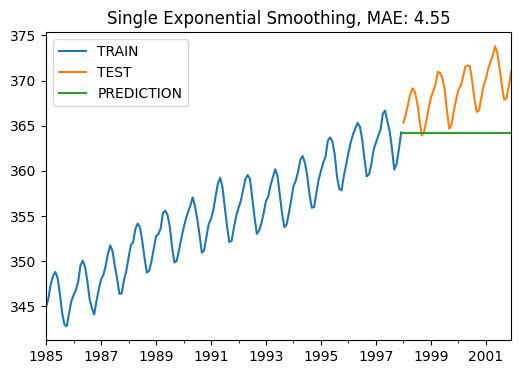

In [7]:
# Hata oranı en tatmin edici olan best_alpha değeri gelince, modeli son defa fit ediyoruz.
ses_model = SimpleExpSmoothing(train).fit(smoothing_level=best_alpha)
y_pred = ses_model.forecast(48) # 48 adet ileri tahmin

plot_co2(train, test, y_pred, "Single Exponential Smoothing") # En iyi parametreli görselleştirmemizi sunuyoruz.

## Double Exponential Smoothing (DES - Çift Üstel Düzeltme)

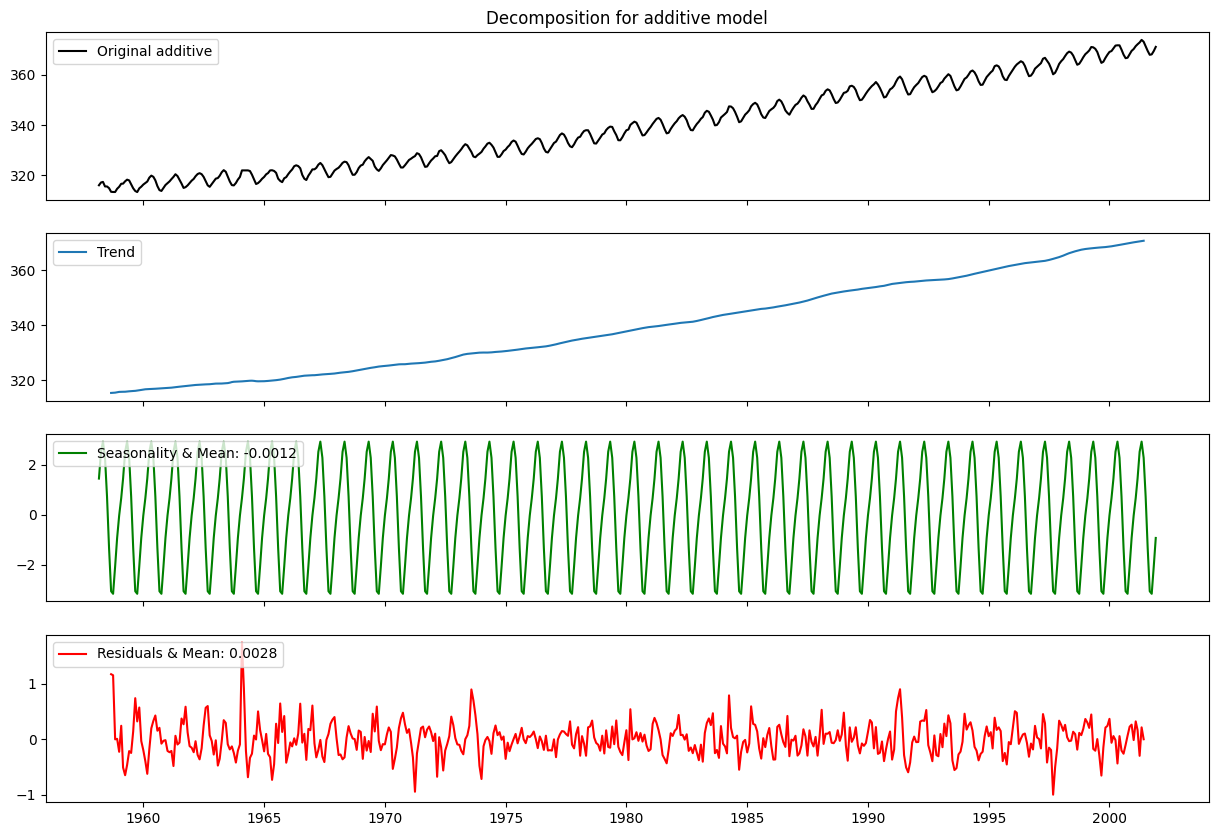

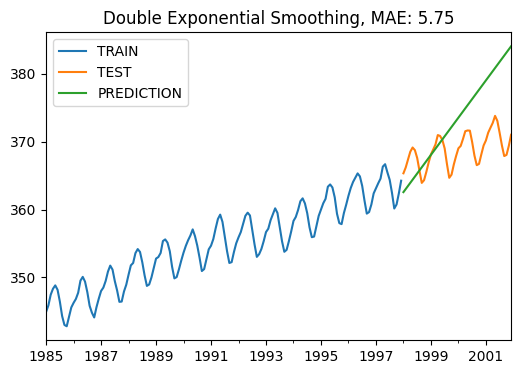

In [8]:
# DES: Level (SES) + Trend 
# (Artık sadece seviye yetmez, bu model veride "yükseliş" veya "düşüş" trendini de öğrenebilir hale geliyor)

# y(t) = Level + Trend + Seasonality + Noise     (Toplamsal Model (add))
# y(t) = Level * Trend * Seasonality * Noise     (Çarpımsal Model (mul))
# Toplamsal demek bu 4 etkinin birbirine eklenerek seriyi oluşturması. Eğer trend mevsimsellikle çığ gibi katlanarak artıyorsa Çarpımsaldır. (Biz toplamsaldan gidiyoruz)

ts_decompose(y) # Nasıl göründüğüne referans hatırlatması.

# 'ExponentialSmoothing' kullanırken trendin yapısını (additive vs. multiplicative) söylemeliyiz. Trend='add' dedik.
# Alpha (smoothing_level) seviyeyi kontrol ederken, Beta (smoothing_trend) ise Trendin ağırlığını kontrol ediyor!
des_model = ExponentialSmoothing(train, trend="add").fit(smoothing_level=0.5,
                                                         smoothing_trend=0.5)

y_pred = des_model.forecast(48) # Yine 48 aylık ileri tahminimiz.

plot_co2(train, test, y_pred, "Double Exponential Smoothing") # Trendi anladığı için sonuç SES'e göre daha yukarı eğilimli akılcı bir sonuç verecektir!

## Hyperparameter Optimization (Çift Parametre İçin Optimizasyon: Alpha ve Beta)

In [9]:
# Az önceki gibi, 0.5 tahmini girmek yerine makineye tüm kombinasyonları deneteceğiz!

def des_optimizer(train, alphas, betas, step=48):
    best_alpha, best_beta, best_mae = None, None, float("inf") # Bu sefer kaydetmek istediğimiz 3 değişkenimiz var (beta dahil).
    
    for alpha in alphas:    # Dış döngü Alpha ağırlıklarını gezer.
        for beta in betas:  # İç döngü ise Beta ağırlıklarını gezer (Böylece her ikisi için olası tüm ikili eşleşmeler denenmiş olur)
            des_model = ExponentialSmoothing(train, trend="add").fit(smoothing_level=alpha, smoothing_slope=beta) # Modeli eğit! (smoothing_slope veya smoothing_trend)
            y_pred = des_model.forecast(step) # Adım sayısı kadar tahminle
            mae = mean_absolute_error(test, y_pred) # Hatanın mutlak değerini ölç.
            
            if mae < best_mae: # En iyi hatayı geçtiyse, best_ değişkenlerini güncelle...
                best_alpha, best_beta, best_mae = alpha, beta, mae
            print("alpha:", round(alpha, 2), "beta:", round(beta, 2), "mae:", round(mae, 4))
    
    print("best_alpha:", round(best_alpha, 2), "best_beta:", round(best_beta, 2), "best_mae:", round(best_mae, 4))
    return best_alpha, best_beta, best_mae

alphas = np.arange(0.01, 1, 0.10) # 0.01 ile 1 arasındaki 0.1 adımlı Alpha liste aralığı.
betas = np.arange(0.01, 1, 0.10)  # Aynı şekilde Trend kontrolcümüz Beta için olan liste ağırlıkları.

# Fonksiyonla en temiz eşleşme neymiş test edip kaydediyoruz.
best_alpha, best_beta, best_mae = des_optimizer(train, alphas, betas)

alpha: 0.01 beta: 0.01 mae: 2.3849
alpha: 0.01 beta: 0.11 mae: 2.8294
alpha: 0.01 beta: 0.21 mae: 2.744
alpha: 0.01 beta: 0.31 mae: 2.1723
alpha: 0.01 beta: 0.41 mae: 2.8895
alpha: 0.01 beta: 0.51 mae: 2.49
alpha: 0.01 beta: 0.61 mae: 1.8196
alpha: 0.01 beta: 0.71 mae: 1.7411
alpha: 0.01 beta: 0.81 mae: 2.1932
alpha: 0.01 beta: 0.91 mae: 4.8522
alpha: 0.11 beta: 0.01 mae: 2.4334
alpha: 0.11 beta: 0.11 mae: 3.9118
alpha: 0.11 beta: 0.21 mae: 6.0908
alpha: 0.11 beta: 0.31 mae: 7.2434
alpha: 0.11 beta: 0.41 mae: 8.7305


alpha: 0.11 beta: 0.51 mae: 10.3166
alpha: 0.11 beta: 0.61 mae: 12.0066
alpha: 0.11 beta: 0.71 mae: 13.9772
alpha: 0.11 beta: 0.81 mae: 16.4873
alpha: 0.11 beta: 0.91 mae: 19.655
alpha: 0.21 beta: 0.01 mae: 2.8218
alpha: 0.21 beta: 0.11 mae: 5.7217
alpha: 0.21 beta: 0.21 mae: 8.6538
alpha: 0.21 beta: 0.31 mae: 11.7598
alpha: 0.21 beta: 0.41 mae: 15.5277
alpha: 0.21 beta: 0.51 mae: 20.1474
alpha: 0.21 beta: 0.61 mae: 25.5273
alpha: 0.21 beta: 0.71 mae: 31.2781
alpha: 0.21 beta: 0.81 mae: 36.4518
alpha: 0.21 beta: 0.91 mae: 39.2485


alpha: 0.31 beta: 0.01 mae: 3.0574
alpha: 0.31 beta: 0.11 mae: 6.6758
alpha: 0.31 beta: 0.21 mae: 10.3271
alpha: 0.31 beta: 0.31 mae: 14.1436
alpha: 0.31 beta: 0.41 mae: 17.8429
alpha: 0.31 beta: 0.51 mae: 20.2123
alpha: 0.31 beta: 0.61 mae: 19.3901
alpha: 0.31 beta: 0.71 mae: 13.7728
alpha: 0.31 beta: 0.81 mae: 3.7074
alpha: 0.31 beta: 0.91 mae: 10.9248
alpha: 0.41 beta: 0.01 mae: 3.1196
alpha: 0.41 beta: 0.11 mae: 6.6882
alpha: 0.41 beta: 0.21 mae: 9.7422
alpha: 0.41 beta: 0.31 mae: 11.6537
alpha: 0.41 beta: 0.41 mae: 11.0982
alpha: 0.41 beta: 0.51 mae: 6.6399
alpha: 0.41 beta: 0.61 mae: 4.0306


alpha: 0.41 beta: 0.71 mae: 13.7751
alpha: 0.41 beta: 0.81 mae: 24.8588
alpha: 0.41 beta: 0.91 mae: 35.269
alpha: 0.51 beta: 0.01 mae: 3.0281
alpha: 0.51 beta: 0.11 mae: 5.8987
alpha: 0.51 beta: 0.21 mae: 7.3654
alpha: 0.51 beta: 0.31 mae: 6.2813
alpha: 0.51 beta: 0.41 mae: 2.5064
alpha: 0.51 beta: 0.51 mae: 7.5608
alpha: 0.51 beta: 0.61 mae: 17.4382
alpha: 0.51 beta: 0.71 mae: 27.8421
alpha: 0.51 beta: 0.81 mae: 37.7406
alpha: 0.51 beta: 0.91 mae: 46.625
alpha: 0.61 beta: 0.01 mae: 2.8595
alpha: 0.61 beta: 0.11 mae: 4.6892


alpha: 0.61 beta: 0.21 mae: 4.3656
alpha: 0.61 beta: 0.31 mae: 2.2806
alpha: 0.61 beta: 0.41 mae: 7.0328
alpha: 0.61 beta: 0.51 mae: 16.0179
alpha: 0.61 beta: 0.61 mae: 25.8633
alpha: 0.61 beta: 0.71 mae: 35.4074
alpha: 0.61 beta: 0.81 mae: 43.8764
alpha: 0.61 beta: 0.91 mae: 50.969
alpha: 0.71 beta: 0.01 mae: 2.6605
alpha: 0.71 beta: 0.11 mae: 3.4216
alpha: 0.71 beta: 0.21 mae: 2.2836
alpha: 0.71 beta: 0.31 mae: 4.6472
alpha: 0.71 beta: 0.41 mae: 12.1538
alpha: 0.71 beta: 0.51 mae: 21.2324
alpha: 0.71 beta: 0.61 mae: 30.3727
alpha: 0.71 beta: 0.71 mae: 38.5569
alpha: 0.71 beta: 0.81 mae: 45.2578
alpha: 0.71 beta: 0.91 mae: 50.323


alpha: 0.81 beta: 0.01 mae: 2.4615
alpha: 0.81 beta: 0.11 mae: 2.5286
alpha: 0.81 beta: 0.21 mae: 2.4107
alpha: 0.81 beta: 0.31 mae: 7.5005
alpha: 0.81 beta: 0.41 mae: 15.4323
alpha: 0.81 beta: 0.51 mae: 24.0296
alpha: 0.81 beta: 0.61 mae: 32.1096
alpha: 0.81 beta: 0.71 mae: 38.7915
alpha: 0.81 beta: 0.81 mae: 43.8094
alpha: 0.81 beta: 0.91 mae: 47.1809
alpha: 0.91 beta: 0.01 mae: 2.2962
alpha: 0.91 beta: 0.11 mae: 2.0983
alpha: 0.91 beta: 0.21 mae: 3.55
alpha: 0.91 beta: 0.31 mae: 9.5526
alpha: 0.91 beta: 0.41 mae: 17.3218


alpha: 0.91 beta: 0.51 mae: 25.2033
alpha: 0.91 beta: 0.61 mae: 32.1161
alpha: 0.91 beta: 0.71 mae: 37.4599
alpha: 0.91 beta: 0.81 mae: 41.15
alpha: 0.91 beta: 0.91 mae: 43.3283
best_alpha: 0.01 best_beta: 0.71 best_mae: 1.7411


## Final DES Model (Sonuç Modeli)

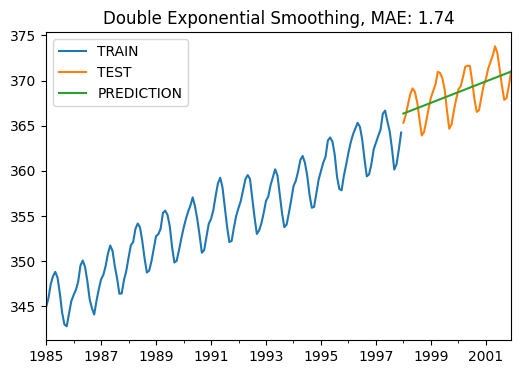

In [10]:
# Ve nihayetinde optimizasyondan kopup gelen mükemmel ikilimizle asıl DES (Çift Düzeltme) metodunu eğiterek kullanıyoruz.
final_des_model = ExponentialSmoothing(train, trend="add").fit(smoothing_level=best_alpha,
                                                               smoothing_slope=best_beta) # Veya smoothing_trend de yazılabilir

y_pred = final_des_model.forecast(48)

plot_co2(train, test, y_pred, "Double Exponential Smoothing")

## Triple Exponential Smoothing (TES - Üçlü Üstel Düzeltme / Holt-Winters)

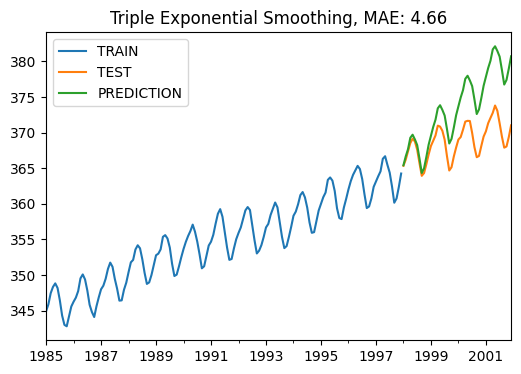

In [11]:
# TES = SES (Level) + DES (Trend) + Mevsimsellik (Seasonality)
# Seriyi adeta bütün dinamikleriyle söküp kavrayan Holt-Winters! Eğer Seride yıllara yayılan dalgalanmalar veya aylar bazında şekillenmeler varsa TEK İHTİYACINIZ T.E.S!


tes_model = ExponentialSmoothing(train,
                                 trend="add",     # Trend etkisini toplamsal baz al! 
                                 seasonal="add",  # Mevsimselliği de toplamsal baz al! (İhtiyaca göre 'mul' - multiplicative yapılabilir).
                                 seasonal_periods=12).fit(smoothing_level=0.5,     # Level için ALPHA ağırlığı
                                                          smoothing_slope=0.5,     # Trend için BETA ağırlığı
                                                          smoothing_seasonal=0.5)  # Mevsimsellik için GAMMA ağırlığı!

y_pred = tes_model.forecast(48) # Holt Winters modelimizle 48 periyot tahmini çek!
plot_co2(train, test, y_pred, "Triple Exponential Smoothing") # Baktığınızda grafik artık mevsimsellik zikzaklarını da çizebildiği için çok daha gerçekçi.

## Hyperparameter Optimization (Alfayı, Betayı ve Gammayı Optimize Etme)

In [12]:
alphas = betas = gammas = np.arange(0.20, 1, 0.10) # 3 katsayıyı da aynı potada listelerde barındır.

# itertools.product bu 3 listeyi alıp bütün o kombinasyon kombinasyon olası çarpım ve eşleşmelerin paketini yaratacak.
abg = list(itertools.product(alphas, betas, gammas))


def tes_optimizer(train, abg, step=48):
    # Bu sefer 4 parametre tutuyoruz: Alpha (Seviye), Beta (Trend), Gamma (Mevsimsellik) ve MAE (Bu kurgudaki çıkan hatamız)
    best_alpha, best_beta, best_gamma, best_mae = None, None, None, float("inf")
    
    # Tüm liste ihtimallerini 'comb' değişkeni aracılığıyla tek tek test döngüsüne sokuyoruz.
    for comb in abg: 
        tes_model = ExponentialSmoothing(train, trend="add", seasonal="add", seasonal_periods=12).\
            fit(smoothing_level=comb[0], smoothing_slope=comb[1], smoothing_seasonal=comb[2]) # comb[0] = alpha, comb[1] = beta, comb[2] = gamma
        y_pred = tes_model.forecast(step)
        mae = mean_absolute_error(test, y_pred)
        
        # Eğer yepyeni düşük bir MAE yakaladıysak rekoru güncelle:
        if mae < best_mae:
            best_alpha, best_beta, best_gamma, best_mae = comb[0], comb[1], comb[2], mae
        print([round(comb[0], 2), round(comb[1], 2), round(comb[2], 2), round(mae, 2)])

    print("best_alpha:", round(best_alpha, 2), "best_beta:", round(best_beta, 2), "best_gamma:", round(best_gamma, 2),
          "best_mae:", round(best_mae, 4))

    return best_alpha, best_beta, best_gamma, best_mae

best_alpha, best_beta, best_gamma, best_mae = tes_optimizer(train, abg) # Optimizasyon başlatıldı ve optimum (alfa, beta, gamma) çekildi!

[np.float64(0.2), np.float64(0.2), np.float64(0.2), 0.88]
[np.float64(0.2), np.float64(0.2), np.float64(0.3), 0.79]
[np.float64(0.2), np.float64(0.2), np.float64(0.4), 0.76]
[np.float64(0.2), np.float64(0.2), np.float64(0.5), 0.75]
[np.float64(0.2), np.float64(0.2), np.float64(0.6), 0.72]
[np.float64(0.2), np.float64(0.2), np.float64(0.7), 0.67]
[np.float64(0.2), np.float64(0.2), np.float64(0.8), 0.67]
[np.float64(0.2), np.float64(0.2), np.float64(0.9), 0.71]
[np.float64(0.2), np.float64(0.3), np.float64(0.2), 0.86]


[np.float64(0.2), np.float64(0.3), np.float64(0.3), 0.93]
[np.float64(0.2), np.float64(0.3), np.float64(0.4), 0.94]
[np.float64(0.2), np.float64(0.3), np.float64(0.5), 0.95]
[np.float64(0.2), np.float64(0.3), np.float64(0.6), 1.09]
[np.float64(0.2), np.float64(0.3), np.float64(0.7), 1.43]
[np.float64(0.2), np.float64(0.3), np.float64(0.8), 1.95]
[np.float64(0.2), np.float64(0.3), np.float64(0.9), 1.73]
[np.float64(0.2), np.float64(0.4), np.float64(0.2), 1.63]
[np.float64(0.2), np.float64(0.4), np.float64(0.3), 1.74]


[np.float64(0.2), np.float64(0.4), np.float64(0.4), 1.64]
[np.float64(0.2), np.float64(0.4), np.float64(0.5), 1.68]
[np.float64(0.2), np.float64(0.4), np.float64(0.6), 2.3]
[np.float64(0.2), np.float64(0.4), np.float64(0.7), 4.39]
[np.float64(0.2), np.float64(0.4), np.float64(0.8), 11.66]
[np.float64(0.2), np.float64(0.4), np.float64(0.9), 4.52]
[np.float64(0.2), np.float64(0.5), np.float64(0.2), 2.46]
[np.float64(0.2), np.float64(0.5), np.float64(0.3), 2.52]
[np.float64(0.2), np.float64(0.5), np.float64(0.4), 1.94]
[np.float64(0.2), np.float64(0.5), np.float64(0.5), 1.82]


[np.float64(0.2), np.float64(0.5), np.float64(0.6), 1.84]
[np.float64(0.2), np.float64(0.5), np.float64(0.7), 3.35]
[np.float64(0.2), np.float64(0.5), np.float64(0.8), 4.63]
[np.float64(0.2), np.float64(0.5), np.float64(0.9), 3.48]
[np.float64(0.2), np.float64(0.6), np.float64(0.2), 3.37]
[np.float64(0.2), np.float64(0.6), np.float64(0.3), 3.11]
[np.float64(0.2), np.float64(0.6), np.float64(0.4), 0.72]
[np.float64(0.2), np.float64(0.6), np.float64(0.5), 1.08]


[np.float64(0.2), np.float64(0.6), np.float64(0.6), 1.64]
[np.float64(0.2), np.float64(0.6), np.float64(0.7), 2.68]
[np.float64(0.2), np.float64(0.6), np.float64(0.8), 3.02]
[np.float64(0.2), np.float64(0.6), np.float64(0.9), 2.92]
[np.float64(0.2), np.float64(0.7), np.float64(0.2), 4.72]
[np.float64(0.2), np.float64(0.7), np.float64(0.3), 4.56]


...

[np.float64(0.9), np.float64(0.8), np.float64(0.6), 6.31]
[np.float64(0.9), np.float64(0.8), np.float64(0.7), 71.79]
[np.float64(0.9), np.float64(0.8), np.float64(0.8), 4972.35]


[np.float64(0.9), np.float64(0.8), np.float64(0.9), 18458.48]
[np.float64(0.9), np.float64(0.9), np.float64(0.2), 18.13]
[np.float64(0.9), np.float64(0.9), np.float64(0.3), 5.36]


[np.float64(0.9), np.float64(0.9), np.float64(0.4), 4.83]
[np.float64(0.9), np.float64(0.9), np.float64(0.5), 8.4]
[np.float64(0.9), np.float64(0.9), np.float64(0.6), 13.91]


[np.float64(0.9), np.float64(0.9), np.float64(0.7), 490.24]
[np.float64(0.9), np.float64(0.9), np.float64(0.8), 16491.85]


[np.float64(0.9), np.float64(0.9), np.float64(0.9), 2768.11]
best_alpha: 0.8 best_beta: 0.7 best_gamma: 0.7 best_mae: 0.6131


## Final TES Model (Holt-Winters Son Karar)

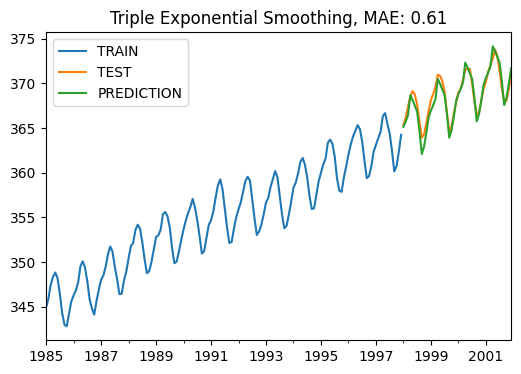

In [13]:
# Üst düzey makine öğrenmesi algısında optimize ettiğimiz hiperparametrelerimizle modelimizi ebedi ikametgahına alıyoruz:
final_tes_model = ExponentialSmoothing(train, trend="add", seasonal="add", seasonal_periods=12).\
            fit(smoothing_level=best_alpha, smoothing_trend=best_beta, smoothing_seasonal=best_gamma)

# Son bir kez tahminde bulunuyoruz...
y_pred = final_tes_model.forecast(48)

# Tahmini ve test edilecek olan doğruluk oranlarını sunuyoruz! Çok güzel örtüştüğünü göreceksiniz.
plot_co2(train, test, y_pred, "Triple Exponential Smoothing")